13 April 2025

6. Gün
* Giriş ve Temel Kavramlar
* Temel Lineer Regresyon
* Çoklu Lineer Regresyon
* Regresyonun İleri Teknikleri

---

### Giriş ve Temel Kavramlar

#### Regresyon Analizi
* Regresyon analizi, bir bağımlı değişkenin (sonuç) bir veya daha fazla bağımsız değişkenle (girdiler) olan ilişkisini modellemeye yönelik bir istatistiksel tekniktir.
* Değişkenler arasındaki ilişkiyi anlamak ve gelecekteki gözlemler için tahmin yapmak amacıyla kullanılır.
* Ekonomi, finans, biyoloji, mühendislik, sosyal bilimler gibi birçok alanda uygulanır.

---

#### Regresyon Temel Kavramlar
* **Bağımlı Değişken (y)**: Sonuç veya tahmin edilmek istenen değişken.
  * Örnek: Ev fiyatları, satış rakamları.
* **Bağımsız Değişken (x)**: Bağımlı değişkeni etkileyen faktörler.
  * Örnek: Ev büyüklüğü, oda sayısı, lokasyon.
* **Regresyon Modeli**:
  \[
  y = \beta_0 + \beta_1 \cdot x_1 + e
  \]
  * \(\beta_0\): Sabit terim (intercept).
  * \(\beta_1\): Regresyon/eğim katsayısı (slope).
  * \(e\): Hata terimi (residual).

---

#### Regresyon Temel Kavramlar
* **Yapısal Veri**: Düzenli aralıklarla veya belirli bir formatta toplanan veriler.
  * Örnek: Anket sonuçları, satış verileri.
* **Zaman Serisi Verisi**: Zaman içinde belirli aralıklarla toplanan veri.
  * Örnek: Aylık satışlar, günlük sıcaklıklar.
* **Panel Veri**: Farklı birey veya birimlerin zaman içinde gözlemlendiği veri.
  * Örnek: Ülkelerin yıllık büyüme oranları.

---

### R^2 (Determination coefficient)
* Açıklama: R², modelin bağımlı değişkendeki varyansın ne kadarını açıkladığını gösterir. 0 ile 1 arasında bir değerdir; 1 modelin bağımlı değişkendeki tüm varyasyonunu açıkladığını, 0 ise modelin hiçbir şeyi açıklamadığını gösterir.
* Kullanımı: Yüksek R² değeri, modelin veriye iyi uyduğunu ve iyi bir tahmin yapabildiğini gösterir.

---

### MSE (Mean Squared Error)
* Açıklama: MSE, tahmin edilen değerler ile gerçek değerler arasındaki farkların karelerinin ortalamasını alır. Kare alma işlemi pozitif ve negatif hataları aynı şekilde cezalandırır ve büyük hataları daha fazla önemser.
* Kullanımı: Daha düşük MSE değerleri, modelin daha doğru tahminler yaptığını gösterir. Ancak MSE'nin ölçüm bağımlı değişkenin birimine bağlı olduğundan, yorumlanması diğer metrikler ile birlikte yapılmalıdır.

---

### Root Mean Squared Error (RMSE)
* Açıklama: RMSE, MSE'nin kareköküdür. Gerçek ve tahmin edilen değerler arasındaki farkın ortalama büyüklüğünü verir.
* Kullanımı: RMSE, MSE'nin birimiyle aynı birimi kullandığından, modelin tahmin doğruluğunu daha anlaşılır bir şekilde ifade eder.

---

### Mean Absolute Error (MAE)
* Açıklama: MAE, tahmin edilen değerler ile gerçek değerler arasındaki farkların mutlak değerlerinin ortalamasıdır.
* Kullanımı: MAE, ortalama tahmin hatasını verir ve diğer metriklerle birlikte kullanıldığında modelin genel performansını değerlendirmek için kullanılır.

---

### Adjusted R^2
* Açıklama: Adjusted R², R²'yi düzeltilmiş bir şekilde ifade eder ve modeldeki bağımsız değişken sayısını da dikkate alır. Modeldeki gereksiz değişkenlerin etkisini azaltmak için kullanılır.
* Kullanımı: Bağımsız değişken sayısı arttıkça R² değeri de artabilir. Bu nedenle Adjusted R² daha güvenilir bir performans ölçütü olarak kabul edilir.

---

### Genel Tablo
| Metrik         | Açıklama                                                                 | Kullanım                                                                                     |
|----------------|--------------------------------------------------------------------------|---------------------------------------------------------------------------------------------|
| R^2           | Modelin bağımlı değişkendeki varyansın ne kadarını açıkladığını gösterir. | Yüksek R^2 değerleri, modelin veriye iyi uyduğunu gösterir.                                 |
| MSE           | Tahmin edilen değerler ile gerçek değerler arasındaki farkların karelerinin ortalamasını alır. | Daha düşük MSE değerleri, modelin daha doğru tahminler yaptığını gösterir.                  |
| RMSE          | MSE'nin kareköküdür. Gerçek ve tahmin edilen değerler arasındaki farkın ortalama büyüklüğünü verir. | RMSE, MSE'nin birimiyle aynı birimi kullandığından, modelin tahmin doğruluğunu daha anlaşılır bir şekilde ifade eder. |
| MAE           | Tahmin edilen değerler ile gerçek değerler arasındaki farkların mutlak değerlerinin ortalamasıdır. | MAE, ortalama tahmin hatasını verir ve diğer metriklerle birlikte kullanıldığında modelin genel performansını değerlendirmek için kullanılır. |
| Adjusted R^2  | R^2'yi düzeltilmiş bir şekilde ifade eder ve modeldeki bağımsız değişken sayısını dikkate alır. | Modeldeki gereksiz değişkenlerin etkisini azaltmak için kullanılır.                         |



Lineer Regresyon

In [ ]:
import numpy as np
import pandas as pd

data = {
    "ev_boyutu": [50, 60, 70, 80, 90, 100, 110, 120, 130, 140],
    "ev_fiyat" : [200000, 250000, 300000, 350000, 400000, 450000, 500000, 550000, 600000, 650000]
}
df = pd.DataFrame(data)
df

In [ ]:
X=df[['ev_boyutu']] # cift tırnak içinde yazmak zorundayız çünkü birden fazla değişken olabilir
y=df.ev_boyutu

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

In [ ]:
y_pred = model.predict(X_test)
print(y_test)
print(y_pred)

In [ ]:
import matplotlib.pyplot as plt

# Sonuçları görselleştirme
plt.scatter(X_train, y_train, color='blue', label='Eğitim Verisi',alpha=0.6, s=100)  # Eğitim verisini göstermek için
plt.scatter(X_test, y_test, color='green', label='Gerçek Test Verisi',alpha=0.6, s=500)  # Gerçek test verisini göstermek için
plt.scatter(X_test, y_pred, color='red', label='Tahmin Edilen Değerler')  # Tahmin edilen değerleri göstermek için
plt.xlabel('Ev Büyüklüğü (m²)')
plt.ylabel('Ev Fiyatı (TL)')
plt.title('Ev Fiyatı Tahmini')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Modelin katsayısı ve doğruluk ölçümleri
# Değerlendirme metrikleri
# Sabit terim (intercept) ve eğim katsayısı (slope)
print(f'β0 (Sabit terim): {model.intercept_}')
print(f'β1 (Eğim katsayısı): {model.coef_[0]}')

# R² skoru
r2 = r2_score(y_test, y_pred)
print(f'R² Score: {r2}')

# Adjusted R² skoru
n = X_test.shape[0]  # Gözlem sayısı
p = X_test.shape[1]  # Bağımsız değişken sayısı
try:
    adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    print(f'Adjusted R² Score: {adjusted_r2}')
except ZeroDivisionError:
    adjusted_r2 = 0
    print(f'Adjusted R² Score: {adjusted_r2}')

# Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error (MSE): {mse}')

# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
print(f'Root Mean Squared Error (RMSE): {rmse}')

# Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)
print(f'Mean Absolute Error (MAE): {mae}')

### Multiple Linear Regression (Çoklu Lineer Regresyon)
* Y = \(\beta_0 + \beta_1 \cdot x_1 + \beta_2 \cdot x_2 + ... + \beta_n \cdot x_n + e\)
* **y**: Bağımlı değişken (tahmin etmek istediğimiz değişken).
* **β₀**: Sabit terim (kesişim noktası).
* **β₁, β₂, ...**: Regresyon katsayıları (bağımsız değişkenlerin bağımlı değişken üzerindeki etkisini gösterir).
* **x₁, x₂, ...**: Bağımsız değişkenler (tahmin etmek için kullandığımız değişkenler).
* **e**: Hata terimi (modelin açıklayamadığı varyasyonu temsil eder).

---

### Neden Çoklu Doğrusal Regresyon?
* **Karmaşık ilişkilerin analizi**: Birden fazla değişken arasındaki karmaşık ilişkileri modelleyerek daha iyi tahminler yapmamızı sağlar.
* **Varyansın açıklanması**: Bağımlı değişkendeki varyansın büyük bir kısmını açıklayarak daha iyi bir model oluşturmanıza yardımcı olur.
* **Karar verme**: Elde edilen sonuçlar sayesinde daha iyi kararlar vermemizi sağlar.
* **Özetle**: Çoklu doğrusal regresyon, birden fazla bağımsız değişkenin bir bağımlı değişken üzerindeki etkisini anlamak ve tahmin yapmak için kullanılır. Bu sayede karmaşık ilişkileri modelleyerek daha iyi tahminler yapabiliriz.

Multiple Lineer Regression

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# California Housing veri setini yükleyin
housing = fetch_california_housing()

# Veriyi DataFrame'e dönüştürün
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  
count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
dtype: float64


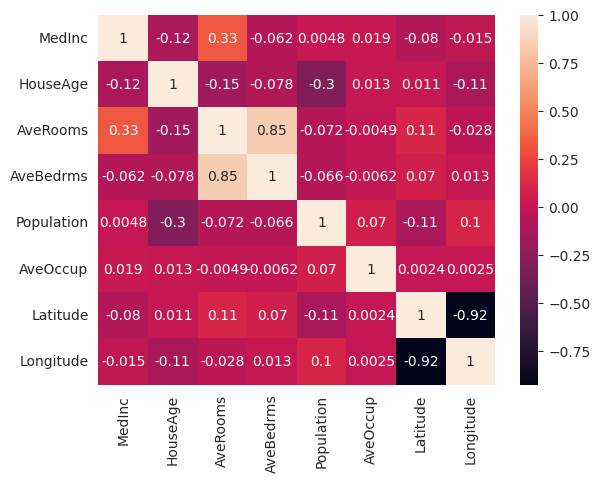

In [3]:
# İlk 5 satırı inceleme
print(X.head())

# Hedef değişkenin istatistiksel özeti
print(pd.Series(y).describe())

# Özellikler arasındaki korelasyon matrisi
corr_matrix = X.corr()
sns.heatmap(corr_matrix, annot=True)
plt.show()

In [4]:
# Veriyi eğitim ve test setlerine ayırın
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
linear_model=LinearRegression()
linear_model.fit(X_train, y_train)

LinearRegression()

In [6]:
y_pred = linear_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error (MSE): {mse}')
print(f'R² Score: {r2}')

Mean Squared Error (MSE): 0.5558915986952443
R² Score: 0.5757877060324508


In [7]:
print(f'Katsayılar: {linear_model.coef_}')
print(f'Sabit Terim: {linear_model.intercept_}')

Katsayılar: [ 4.48674910e-01  9.72425752e-03 -1.23323343e-01  7.83144907e-01
 -2.02962058e-06 -3.52631849e-03 -4.19792487e-01 -4.33708065e-01]
Sabit Terim: -37.023277706064185


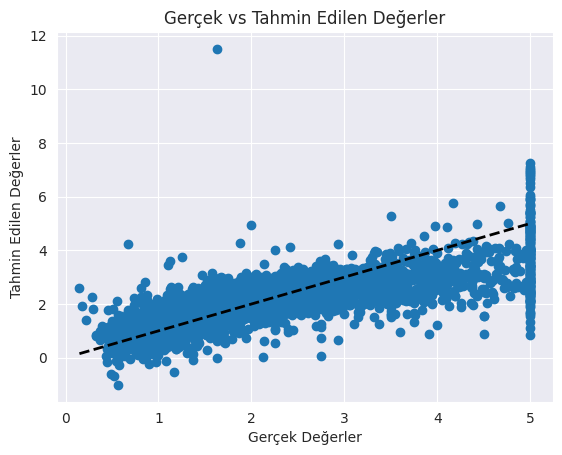

In [8]:
plt.scatter(y_test, y_pred)
plt.xlabel('Gerçek Değerler')
plt.ylabel('Tahmin Edilen Değerler')
plt.title('Gerçek vs Tahmin Edilen Değerler')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.show()

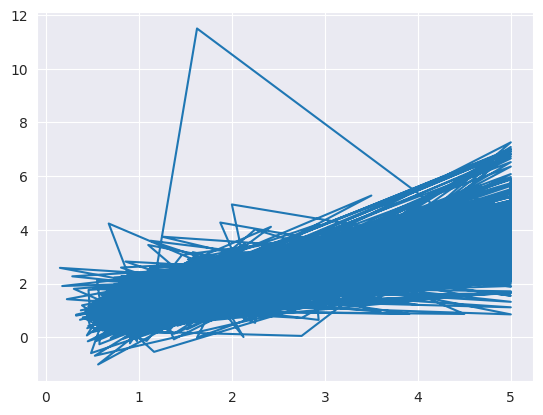

In [9]:
plt.plot(y_test, y_pred)
plt.show()

Diğer regresyon türleri # tablo


Ridge regression
* ridge resgresyonu özellikwe çoklu doğrusal regresyon modelerde overfiting sorunun çözmek ve modelin genleeme yeteğini artımak için kullanılan bir düzenleme yöntemidir.
* en küçük

Lasso Regression
* istatisk ve makine öğrenimi alanındasıklıkla kullanılır.
* özellikle çoklu dorğısal bağlantı

Ridge vs Lasso Regresyon # tablo

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Veri setini yükleme (California Ev Fiyatları)
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()
X = housing.data
y = housing.target

# Veriyi ölçeklendirme (önemli!)
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Farklı alpha değerleri için Ridge regresyonu ve değerlendirme
alphas = [0.1, 1.0, 10.0, 100.0]
for alpha in alphas:
    # Ridge regresyon modeli oluşturma
    ridge_reg = Ridge(alpha=alpha)

    # Modeli eğitme
    ridge_reg.fit(X_train, y_train)

    # Test setinde tahmin yapma
    y_pred = ridge_reg.predict(X_test)

    # Değerlendirme metrikleri
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"Alpha = {alpha}")
    print(f"  MSE: {mse:.2f}")
    print(f"  MAE: {mae:.2f}")
    print(f"  R-squared: {r2:.2f}")

# En iyi modelin katsayılarına bakma (örneğin, alpha=1 için)
best_alpha = 1.0
best_model = Ridge(alpha=best_alpha)
best_model.fit(X_train, y_train)
print("En iyi modelin katsayıları:")
print(best_model.coef_)

Alpha = 0.1
  MSE: 0.56
  MAE: 0.53
  R-squared: 0.58
Alpha = 1.0
  MSE: 0.56
  MAE: 0.53
  R-squared: 0.58
Alpha = 10.0
  MSE: 0.56
  MAE: 0.53
  R-squared: 0.58
Alpha = 100.0
  MSE: 0.55
  MAE: 0.53
  R-squared: 0.58
En iyi modelin katsayıları:
[ 0.85231009  0.12246004 -0.3048709   0.37081855 -0.00227294 -0.03662725
 -0.89588451 -0.86816501]


Elastic net regresoynu
* ridge ve lasso regresyonlarının en iyi özelliklerini bir araya getiren hibrit bir düzenleme yöntemidir.
* hem dğeişken seçimi yapnma yeteğini lasso hem de çoklu doğrusal nağlantı sorununa karşıdayankılıık ridge gibi avantajlar sunar
* ridge ve lasso nun birleştimi
* Esnelik: elastic net iki farklı düzenleme paramresine sahiptir
* Çoklu doğrusal bağlantı: korelasyonu yğjsej olan değişkenlerin olduğu durumlarda elastic net lasso gibi değişken seçimi yaparak bu sorunu çözer.




In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Veri setini yükleme (California Ev Fiyatları)
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()
data = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

# Veriyi ölçeklendirme
scaler = StandardScaler()
X = scaler.fit_transform(data)

# Eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Farklı alpha ve l1_ratio değerleri için Elastic Net regresyonu ve değerlendirme
alphas = [0.01, 0.1, 0.5]#karmaşıklığını kontrol ederek aşırı öğrenmeyi (overfitting) önlemeye yardımcı olur
l1_ratios = [0.2, 0.5, 0.8]#0 değeri Ridge'e, 1 değeri Lasso'ya karşılık gelir.

for alpha in alphas:
    for l1_ratio in l1_ratios:
        # Elastic Net regresyon modeli oluşturma
        elastic_net = ElasticNet(alpha=alpha, l1_ratio=l1_ratio)

        # Modeli eğitme
        elastic_net.fit(X_train, y_train)

        # Test setinde tahmin yapma
        y_pred = elastic_net.predict(X_test)

        # Değerlendirme metrikleri
        mse = mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        print(f"Alpha = {alpha}, l1_ratio = {l1_ratio}")
        print(f"  MSE: {mse:.2f}")
        print(f"  MAE: {mae:.2f}")
        print(f"  R-squared: {r2:.2f}")

# En iyi modelin katsayılarına bakma (örneğin, alpha=1, l1_ratio=0.5 için)
best_alpha = 0.01
best_l1_ratio = 0.5
best_model = ElasticNet(alpha=best_alpha, l1_ratio=best_l1_ratio)
best_model.fit(X_train, y_train)
print("En iyi modelin katsayıları:")
print(best_model.coef_)

# Hangi özellikler seçildi?
selected_features = data.columns[best_model.coef_ != 0]
print("Seçilen özellikler:", selected_features)

Alpha = 0.01, l1_ratio = 0.2
  MSE: 0.55
  MAE: 0.53
  R-squared: 0.58
Alpha = 0.01, l1_ratio = 0.5
  MSE: 0.55
  MAE: 0.53
  R-squared: 0.58
Alpha = 0.01, l1_ratio = 0.8
  MSE: 0.55
  MAE: 0.53
  R-squared: 0.58
Alpha = 0.1, l1_ratio = 0.2
  MSE: 0.60
  MAE: 0.58
  R-squared: 0.54
Alpha = 0.1, l1_ratio = 0.5
  MSE: 0.64
  MAE: 0.60
  R-squared: 0.51
Alpha = 0.1, l1_ratio = 0.8
  MSE: 0.67
  MAE: 0.62
  R-squared: 0.49
Alpha = 0.5, l1_ratio = 0.2
  MSE: 0.76
  MAE: 0.67
  R-squared: 0.42
Alpha = 0.5, l1_ratio = 0.5
  MSE: 0.83
  MAE: 0.70
  R-squared: 0.37
Alpha = 0.5, l1_ratio = 0.8
  MSE: 0.88
  MAE: 0.73
  R-squared: 0.33
En iyi modelin katsayıları:
[ 0.8194602   0.12989299 -0.21753612  0.27392626  0.         -0.03268378
 -0.78971941 -0.75744488]
Seçilen özellikler: Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup', 'Latitude',
       'Longitude'],
      dtype='object')


Random forest regresyonu
* karar ağaçlarını gücünü birleştirerek güçlü ve esnerk bir tahmin modeli sunar
*  yüksek doğrulur overfffitng i öbleme ve farklı veri türlerini yöbetme gibi özellikleri sayesinde birçok alanda yaygın olarak kullanulunur
* önemli değişkenlerin belirlenmesi
* farklı veri türlerini yönetme
* eksik veri ile başa çıkma




In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing

# Veri setini yükleme (California Ev Fiyatları)
housing = fetch_california_housing()
data = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

# Veriyi eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(data, y, test_size=0.2, random_state=42)

# Random Forest Regresyon modeli oluşturma
rf_regressor = RandomForestRegressor(random_state=42)

# Hiperparametreler için deneme yapılacak değerler
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Grid Search ile en iyi parametreleri bulma
grid_search = GridSearchCV(estimator=rf_regressor, param_grid=param_grid, cv=5)
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_

# En iyi parametrelerle model oluşturma
best_rf = RandomForestRegressor(**best_params)
best_rf.fit(X_train, y_train)

# Test setinde tahmin yapma
y_pred = best_rf.predict(X_test)

# Değerlendirme metrikleri
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("En iyi parametreler:", best_params)
print("Mean Squared Error:", mse)
print("R-squared:", r2)

En iyi parametreler: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
Mean Squared Error: 0.25217022286670737
R-squared: 0.8075637247195742


Polinom regresyon
* doprusal olmayan ilişkiler: doğrusal regresynun doğrusal ilişileri modelleyemediği durumlarda kullanılır
* eğrisel modelleme: veri noktalarına daha iyi uyum sağlamak için eğrisel bir moıdel oluşturur.
* polinom denklemi: Y = β₀ + β₁x + β₂x² + ... + βₙxⁿ şeklinde ifade edilir. burada n polinom derecesidir
* derecenin önemi: derecenin artmasıyla modelin karmaşıklığı artar. çok yüksek dereceler overfitting e neden olabilir.
* kullanım alanları: zaman serisi analizi, finans , makine öğrenmesi , doğal bililmer gibi bir çok alanda kullanılır
* avantajları: doğrusal olmayan ilişkileri modelleyebiir. esnek bir modeldir.
* dezavantajları: overfitting e eğilimlidir. yüksek dereceli polinomlar yorumlanması zordur.


Lineer Regresyon R^2: 0.5758
Ridge Regresyon R^2: 0.5759
Lasso Regresyon R^2: 0.5318
ElasticNet Regresyon R^2: 0.5627
Random Forest Regresyon R^2: 0.8051
Polinomal Regresyon R^2: 0.6457


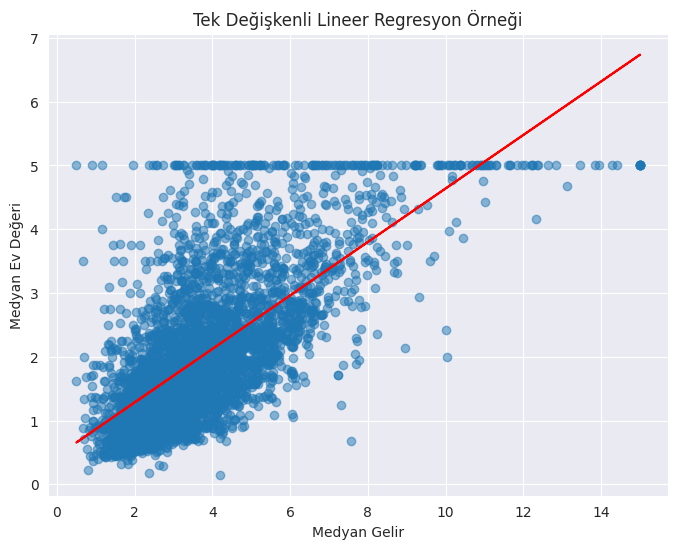

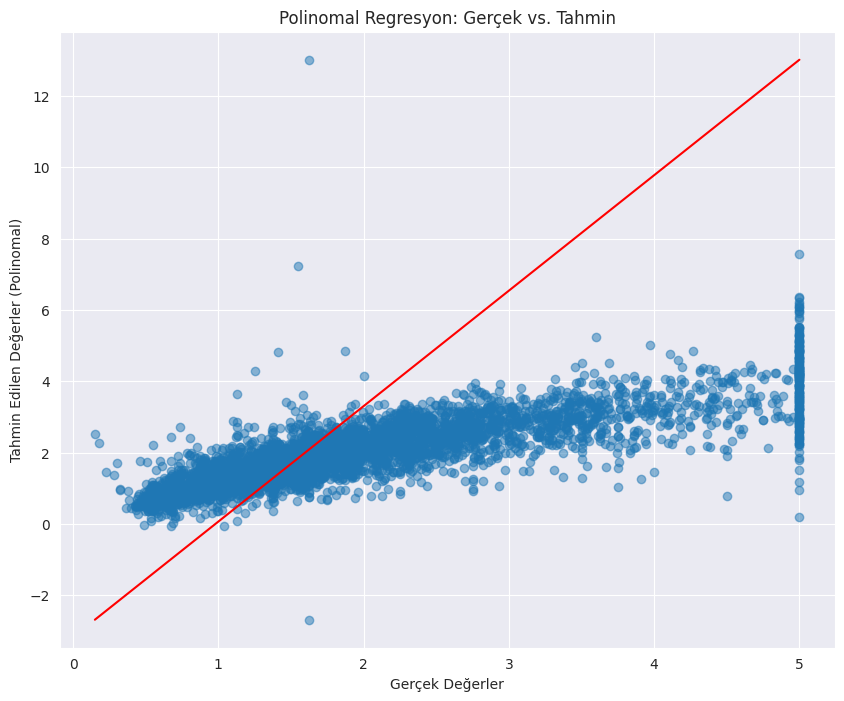

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Veri yükleme ve hazırlama
try:
    california = fetch_california_housing()
    df = pd.DataFrame(california.data, columns=california.feature_names)
    df['MedHouseVal'] = california.target
except Exception as e:
    print(f"Veri yüklenirken hata: {e}")
    exit()

X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modelleri tanımlama ve eğitme
models = {
    "Lineer Regresyon": LinearRegression(),
    "Ridge Regresyon": Ridge(alpha=1.0),  # alpha: düzenlileştirme gücü
    "Lasso Regresyon": Lasso(alpha=0.1),  # alpha: düzenlileştirme gücü
    "ElasticNet Regresyon": ElasticNet(alpha=0.1, l1_ratio=0.5),  # l1_ratio: L1 ve L2 düzenlileştirme oranı
    "Random Forest Regresyon": RandomForestRegressor(n_estimators=100, random_state=42) # n_estimators: ağaç sayısı
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    print(f"{name} R^2: {r2:.4f}")

# Polinomal Regresyon
poly_pipeline = Pipeline([
    ('poly_features', PolynomialFeatures(degree=2)),  # Polinom derecesi
    ('scaler', StandardScaler()),
    ('linear_reg', LinearRegression())
])

poly_pipeline.fit(X_train, y_train)
y_poly_pred = poly_pipeline.predict(X_test)
r2_poly = r2_score(y_test, y_poly_pred)
print(f"Polinomal Regresyon R^2: {r2_poly:.4f}")


# Tek Değişkenli Lineer Regresyon Örneği (örn. gelir vs. ev değeri)
plt.figure(figsize=(8, 6))
plt.scatter(X_test['MedInc'], y_test, alpha=0.5)
plt.xlabel('Medyan Gelir')
plt.ylabel('Medyan Ev Değeri')
plt.title('Tek Değişkenli Lineer Regresyon Örneği')

single_feature_model = LinearRegression()
single_feature_model.fit(X_train[['MedInc']], y_train)
y_pred_single = single_feature_model.predict(X_test[['MedInc']])
plt.plot(X_test['MedInc'], y_pred_single, color='red')
plt.show()


plt.figure(figsize=(10, 8))
plt.scatter(y_test, poly_pipeline.predict(X_test), alpha=0.5)
plt.xlabel("Gerçek Değerler")
plt.ylabel("Tahmin Edilen Değerler (Polinomal)")
plt.title("Polinomal Regresyon: Gerçek vs. Tahmin")
plt.plot([min(y_test), max(y_test)], [min(poly_pipeline.predict(X_test)), max(poly_pipeline.predict(X_test))], color='red')
plt.show()